In [177]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [178]:
df = pd.read_csv('HousingData.csv')

In [179]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [180]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [181]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [182]:
df.shape

(506, 14)

In [183]:
df['AGE'] = df['AGE'].fillna(df['AGE'].mean())


In [184]:
df['AGE'].isna().sum()

np.int64(0)

In [185]:
med_col= ['CRIM','INDUS','CHAS','LSTAT']
df[med_col] = df[med_col].fillna(df[med_col].mean())

In [186]:
df.isna().sum()

,0
CRIM,0
ZN,20
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [187]:
df['ZN'] = df['ZN'].fillna(df['ZN'].mean())


In [188]:
df.shape

(506, 14)

In [189]:
df.duplicated().sum()

np.int64(0)

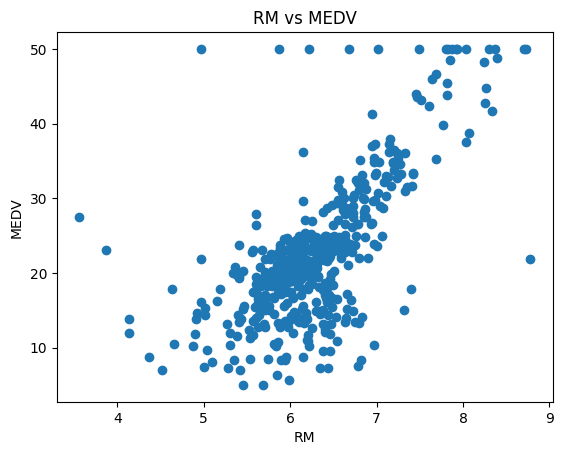

In [190]:
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.title('RM vs MEDV')
plt.show()


In [191]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [192]:
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [193]:
y_pred = model.predict(X_test)
print("Prediction",y_pred)

Prediction [23.83712764 31.85990204 16.11373966 24.06840695 17.1898399  21.44446516
 19.09830225 14.2896668  20.29153858 20.87753064 20.02170626 18.31418171
  7.44235583 21.54313723 19.62085547 28.7061468  18.61196858  8.4504613
 46.56051382 15.30603354 25.37684854 26.04089961 12.97419686 19.39089941
 13.86693655 15.64245499 21.83407243 13.12188835 19.26147712 20.9175613
 20.30464306 23.68276946 18.67597382 19.11047134 14.92366128 16.44902564
 33.56116836 19.19692362 20.76656147 24.06540702 17.3632163  30.0307201
 45.4909734  20.42430812 22.44434544 13.24882229 15.9087942  24.05992423
 18.16944188 26.45373578 21.56009565 34.61195059 16.9429128  25.48152293
 48.31992032 20.97580683 15.39259899 31.69822079 22.41241493 17.4655043
 25.06295785 33.84446105 30.20990529 19.36108373 25.11794799 17.07016898
 13.68986198 23.39933619 28.1465909  15.99728587 21.02169006 24.14645537
  9.92980919 21.08043477 22.80173609  7.03436877 20.14694443 43.90658111
 11.16147211 13.12098228 21.10120348 12.4047

In [194]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error",mae)
r2_score = r2_score(y_test,y_pred)
print("R2 Score",r2_score)

Mean Absolute Error 1.8880812313140465
R2 Score 0.8995740084182966


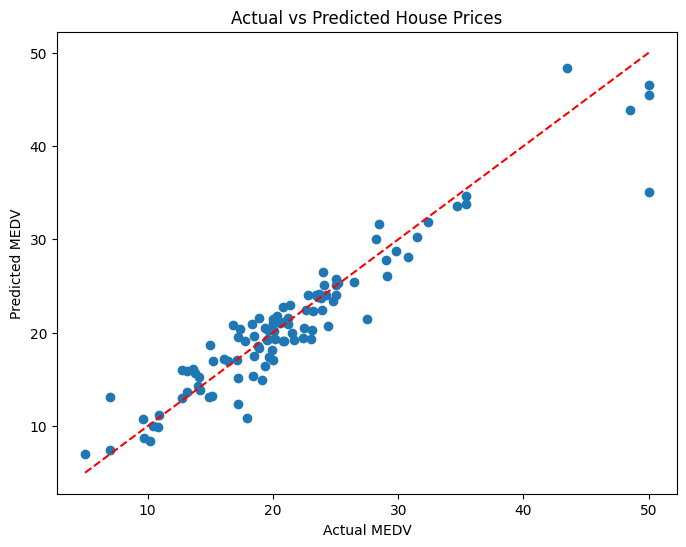

In [195]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [196]:
df.tail(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
505,0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88,11.9


In [197]:
model.predict([[0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


array([14.75815274])

In [198]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result['Difference'] = result['Actual'] - result['Predicted']

print(result.head(20))

     Actual  Predicted  Difference
173    23.6  23.837128   -0.237128
274    32.4  31.859902    0.540098
491    13.6  16.113740   -2.513740
72     22.8  24.068407   -1.268407
452    16.1  17.189840   -1.089840
76     20.0  21.444465   -1.444465
316    17.8  19.098302   -1.298302
140    14.0  14.289667   -0.289667
471    19.6  20.291539   -0.691539
500    16.8  20.877531   -4.077531
218    21.5  20.021706    1.478294
9      18.9  18.314182    0.585818
414     7.0   7.442356   -0.442356
78     21.2  21.543137   -0.343137
323    18.5  19.620855   -1.120855
473    29.8  28.706147    1.093853
124    18.8  18.611969    0.188031
388    10.2   8.450461    1.749539
195    50.0  46.560514    3.439486
448    14.1  15.306034   -1.206034


In [199]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9780850287154358
Test R2: 0.8995740084182966


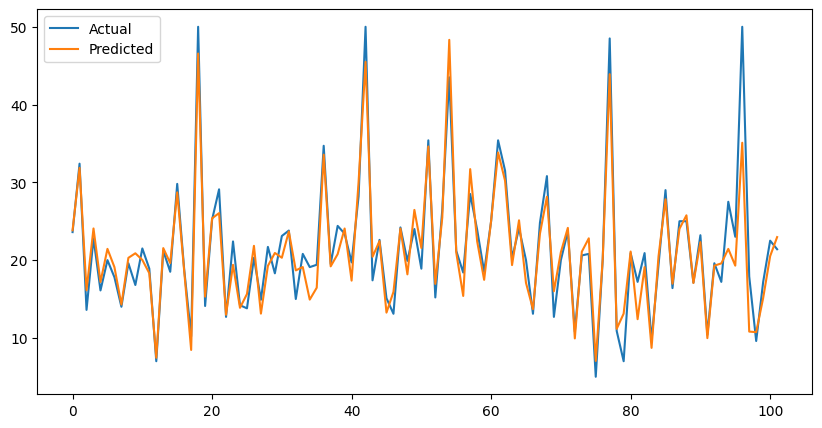

In [200]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label='Actual')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()
plt.show()